In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

**Introduction & visualisation of given data**

Nous travaillons sur un système dynamique multivarié avec deux entrées (U)et deux sorties (Y).

**Analyse des inputs (Utr) :** signaux centrés autour de 0, amplitude globalement entre -2 et 2, fluctuations rapides → pas de tendance claire

**Analyse des outputs (Ytr) :** toujours centré autour de 0, amplitude plus variable, présence de pics (outliers) dynamique plus “structurée” que Utr

--> Les sorties montrent une dynamique plus complexe que les entrées, avec des variations non linéaires et des pics, ce qui suggère un système non linéaire avec du bruit.

**Analyse des histogrammes des entrées** : forme en cloche (gaussienne), centrée autour de 0, symétrique,pas d’outliers extrêmes visibles --> les entrées suivent approximativement : **une distribution normale (bruit blanc)**

**Analyse des histogrammes des sorties** : très concentré autour de 0
pic très élevé (distribution étroite) mais longues queues (outliers)

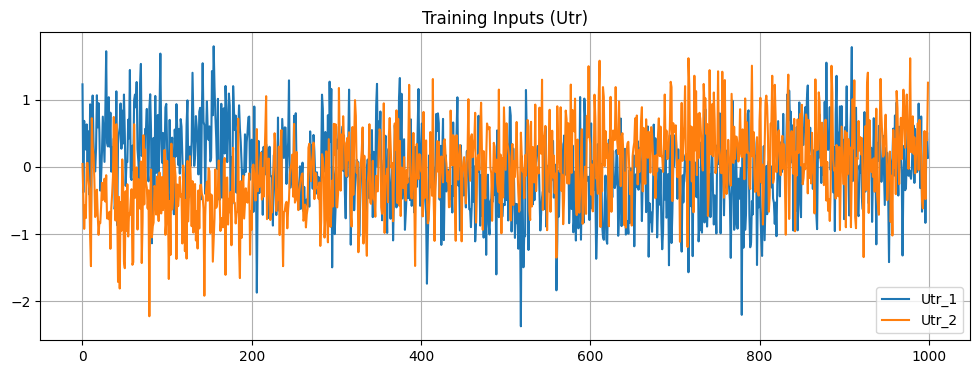

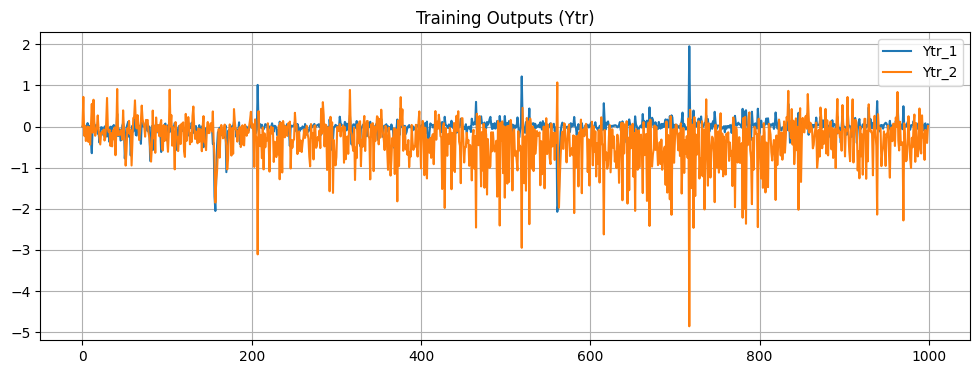

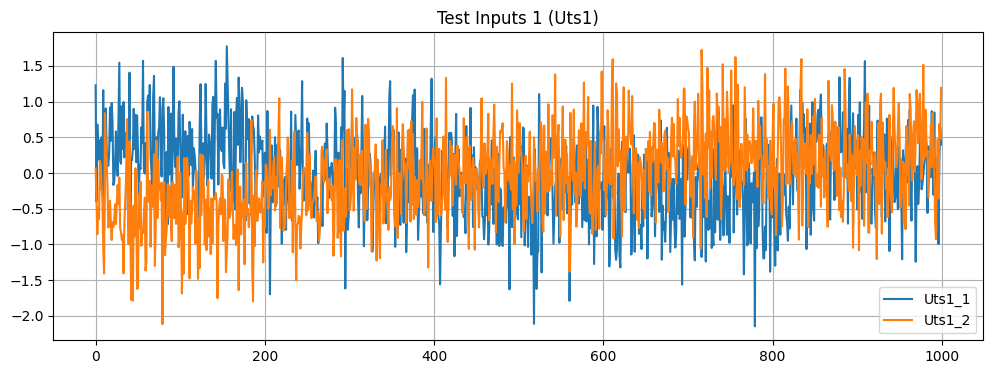

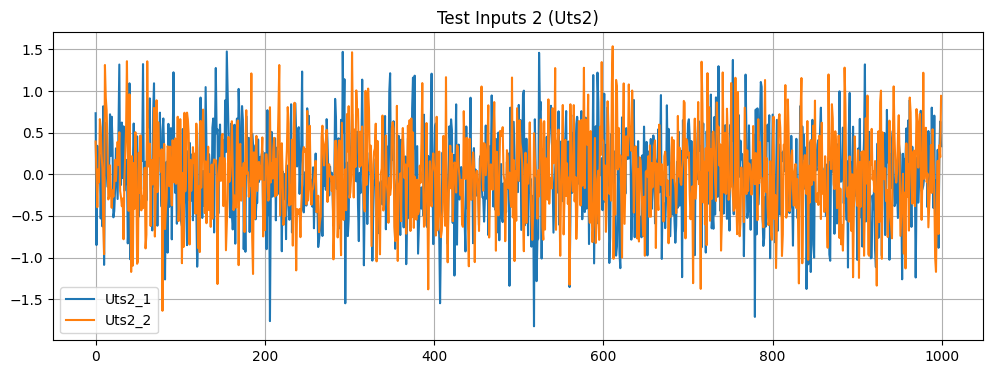

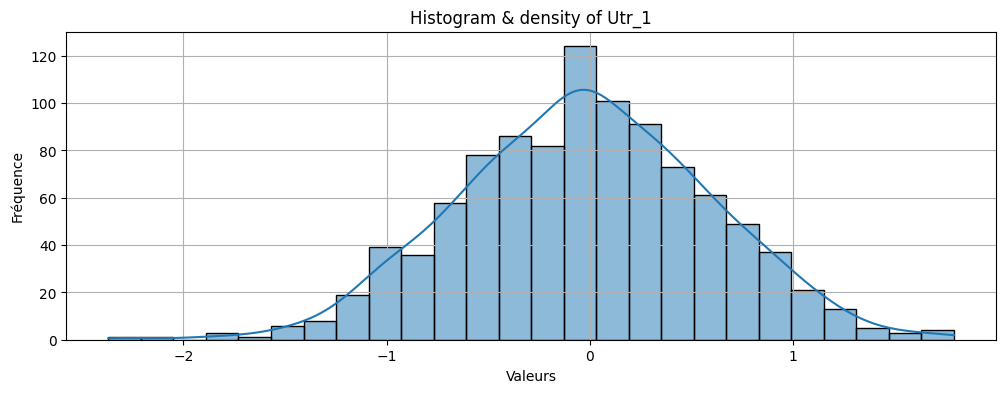

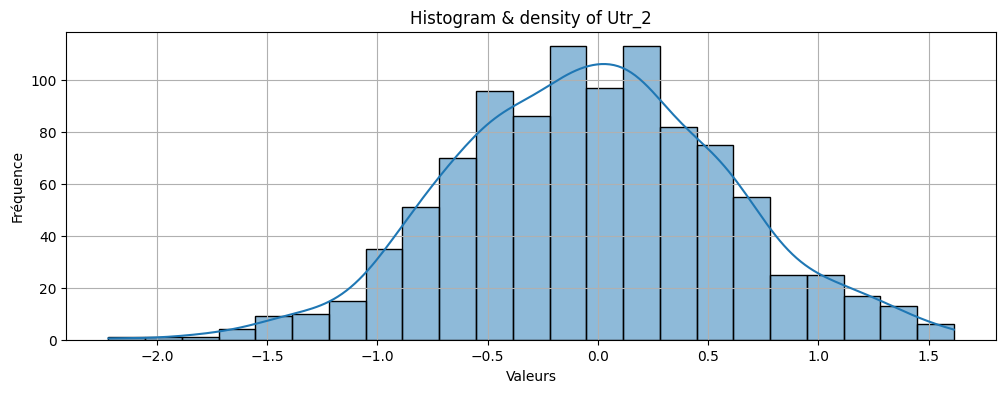

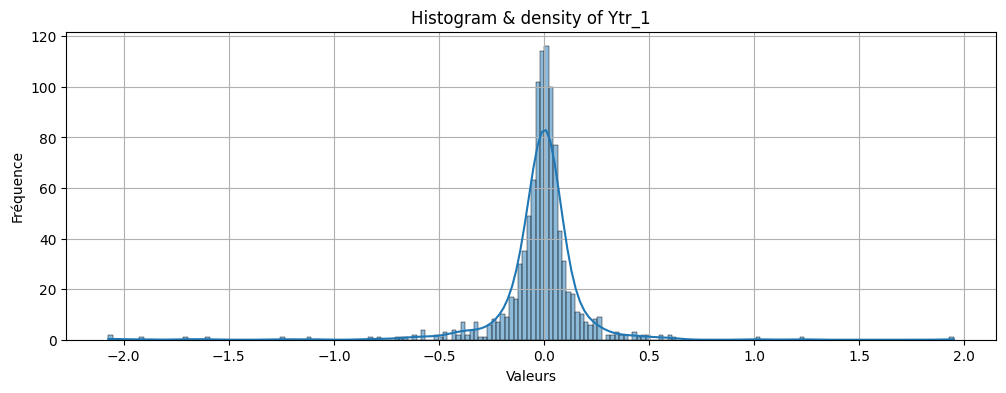

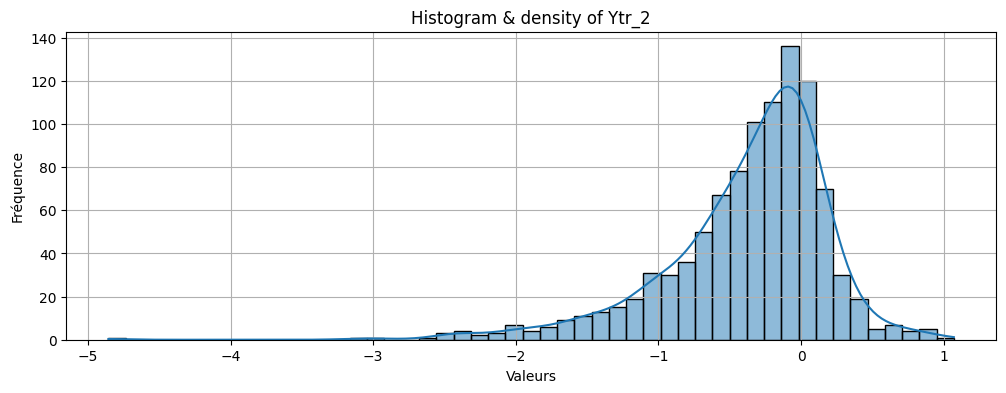

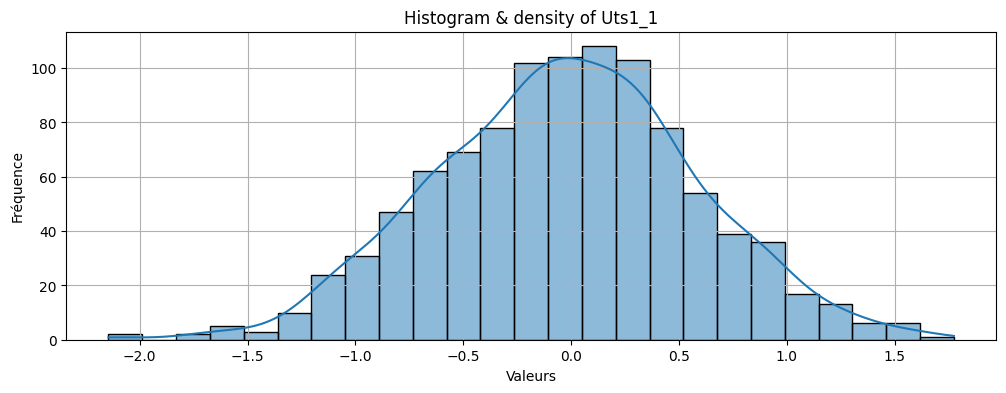

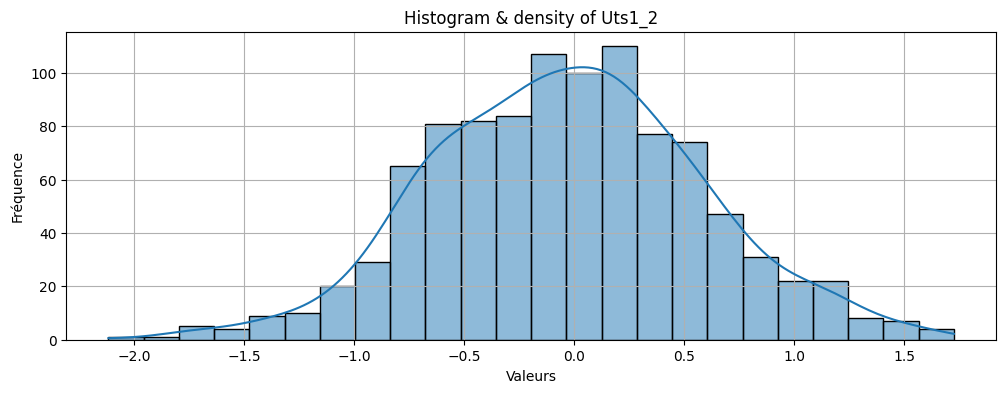

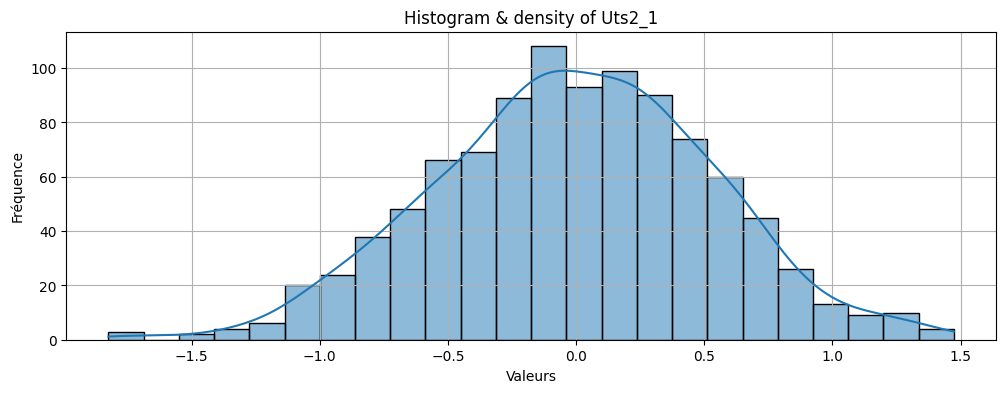

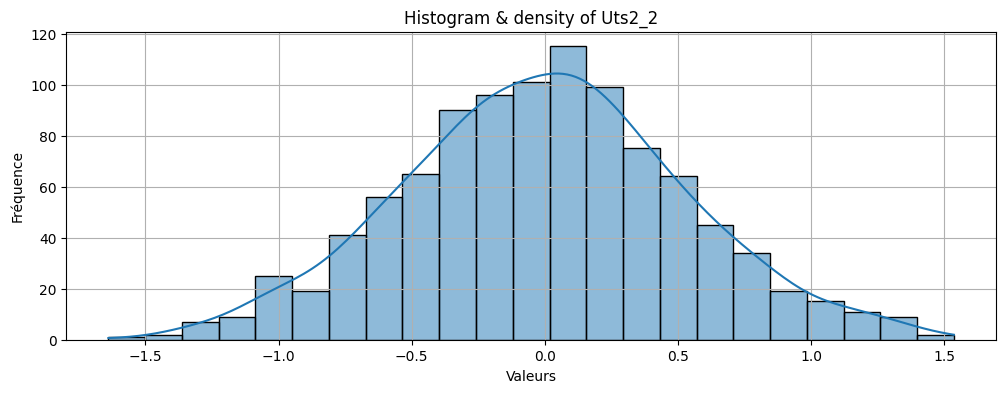

In [2]:
# -------------------------------------------------------
# Load data
# -------------------------------------------------------
Utr = np.load("Utr.npy")   # shape (N, 2)
Ytr = np.load("Ytr.npy")   # shape (N, 2)

Uts1 = np.load("Uts1.npy") # shape (N, 2)
Uts2 = np.load("Uts2.npy") # shape (N, 2)

# -------------------------------------------------------
# TRAINING SET
# -------------------------------------------------------

# Inputs Utr
plt.figure(figsize=(12,4))
plt.plot(Utr[:, 0], label="Utr_1")
plt.plot(Utr[:, 1], label="Utr_2")
plt.title("Training Inputs (Utr)")
plt.legend()
plt.grid()

# Outputs Ytr
plt.figure(figsize=(12,4))
plt.plot(Ytr[:, 0], label="Ytr_1")
plt.plot(Ytr[:, 1], label="Ytr_2")
plt.title("Training Outputs (Ytr)")
plt.legend()
plt.grid()

# -------------------------------------------------------
# TEST SET 1
# -------------------------------------------------------

plt.figure(figsize=(12,4))
plt.plot(Uts1[:, 0], label="Uts1_1")
plt.plot(Uts1[:, 1], label="Uts1_2")
plt.title("Test Inputs 1 (Uts1)")
plt.legend()
plt.grid()

# -------------------------------------------------------
# TEST SET 2
# -------------------------------------------------------

plt.figure(figsize=(12,4))
plt.plot(Uts2[:, 0], label="Uts2_1")
plt.plot(Uts2[:, 1], label="Uts2_2")
plt.title("Test Inputs 2 (Uts2)")
plt.legend()
plt.grid()

plt.show()


def plot_hist(data, title):
    plt.figure(figsize=(12,4))
    sns.histplot(data, kde=True)
    plt.title(title)
    plt.xlabel("Valeurs")
    plt.ylabel("Fréquence")
    plt.grid()
    plt.show()

# -------------------------------------------------------
# Utr
# -------------------------------------------------------
plot_hist(Utr[:, 0], "Histogram & density of Utr_1")
plot_hist(Utr[:, 1], "Histogram & density of Utr_2")

# -------------------------------------------------------
# Ytr
# -------------------------------------------------------
plot_hist(Ytr[:, 0], "Histogram & density of Ytr_1")
plot_hist(Ytr[:, 1], "Histogram & density of Ytr_2")

# -------------------------------------------------------
# Uts1
# -------------------------------------------------------
plot_hist(Uts1[:, 0], "Histogram & density of Uts1_1")
plot_hist(Uts1[:, 1], "Histogram & density of Uts1_2")

# -------------------------------------------------------
# Uts2
# -------------------------------------------------------
plot_hist(Uts2[:, 0], "Histogram & density of Uts2_1")
plot_hist(Uts2[:, 1], "Histogram & density of Uts2_2")

**Task 1**

on génère des données synthétiques à partir de deux systèmes dynamiques non linéaires (Pilot 1 et Pilot 2). L’objectif est de créer un environnement contrôlé pour tester les performances de différents modèles d’identification.

Le premier est simple, le second plus complexe:

**PILOT 1 :**

*   Système dynamique car les sorties dépendent du passé → mémoire (retard k-1)
*   Couplage entre sorties : y1 dépend de y2 et inversement → système MIMO couplé
*   Non-linéarité : présence de sin(y)
*   Influence de l’entrée : u(k) agit directement sur les sorties
→ système contrôlé

DONC : Mémoire court, Couplage simple et données relativement faciles à modéliser

**PILOT 2 :**

*   Produits non linéaires : y(k)⋅y(k−1)⋅y(k−2) →  interactions très complexesÉlément de liste
*   Effet mémoire plus long : dépend de k,k−1,k−2 → mémoire longue
*   Division (non-linéarité forte) : présence d’un dénominateur → comportement instable possible
*   Couplage indirect :y1 dépend de y2. via le dénominateur → couplage plus subtil

DONC : Système fortement non linéaire, Mémoire longue, Interactions complexes, Beaucoup plus difficile à apprendre

 Cela nous permet de tester si nos modèles sont capables d’apprendre des comportements de difficulté différente dans un contexte réaliste avec du bruit

Ainsi, Pilot 1 sert de cas simple pour valider le bon fonctionnement des modèles,
tandis que Pilot 2 constitue un cas difficile permettant d’évaluer leur capacité
à capturer des dynamiques fortement non linéaires et à mémoire longue.

Ce cadre permet donc de comparer différents modèles dans des conditions
progressivement plus complexes et réalistes.

/tmp/ipykernel_2630/365887851.py:31: RuntimeWarning: overflow encountered in scalar multiply
  num1 = y1[k]*y1[k-1]*y1[k-2]*(y1[k-2]-1)*u2[k-1] + u2[k]
/tmp/ipykernel_2630/365887851.py:35: RuntimeWarning: overflow encountered in scalar power
  den2 = 1 + y1[k-1]**2 + y1[k-2]**2


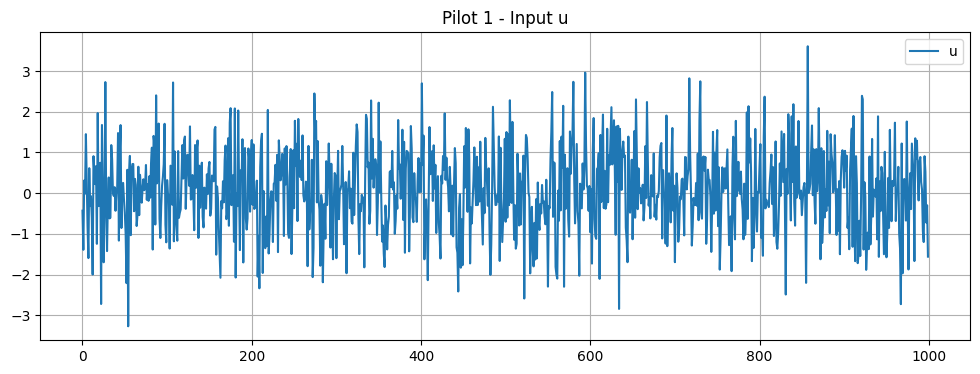

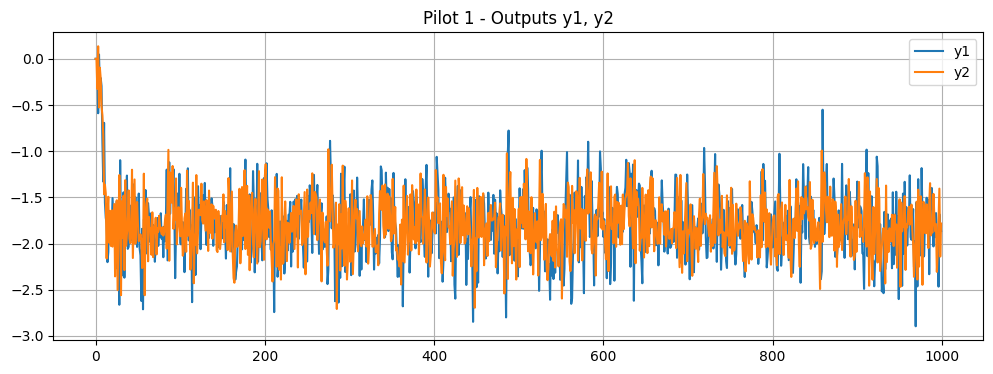

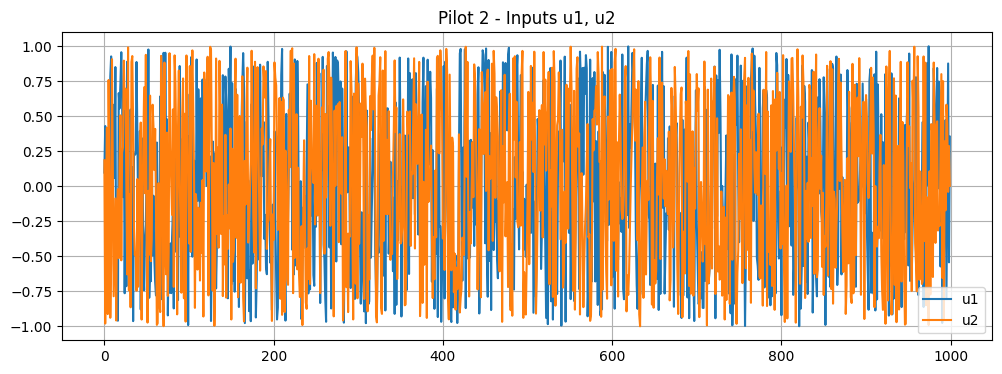

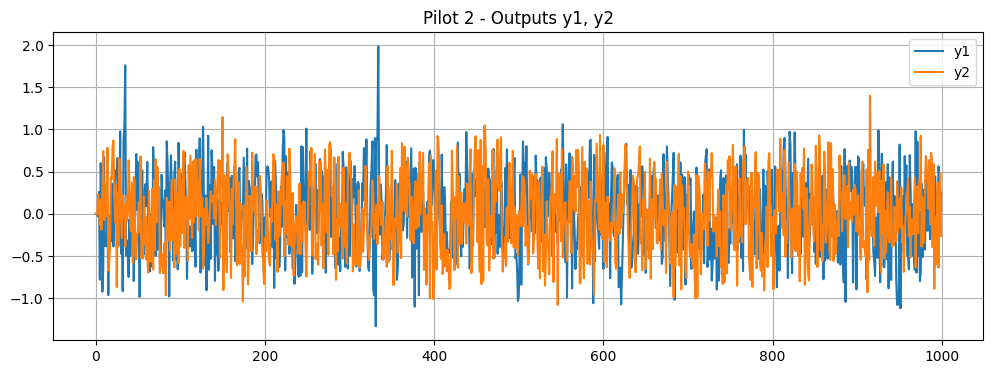

In [3]:
# -------------------------------------------------------
# Simulate pilot 1
# -------------------------------------------------------

def simulate_pilot1(N, noise_var, seed=2026):
    np.random.seed(seed)
    u  = np.random.randn(N)
    w1 = np.random.normal(0, np.sqrt(noise_var), N)
    w2 = np.random.normal(0, np.sqrt(noise_var), N)
    y1 = np.zeros(N)
    y2 = np.zeros(N)
    for k in range(1, N-1):
        y1[k+1] = 0.5*y2[k-1] + np.sin(y2[k]) + 0.3*u[k-1] + w1[k+1]
        y2[k+1] = 0.5*y1[k-1] + np.sin(y1[k]) + 0.2*u[k]   + w2[k+1]
    return u, y1, y2


# -------------------------------------------------------
# Simulate pilot 2
# -------------------------------------------------------

def simulate_pilot2(N, noise_var, seed=0):
    np.random.seed(seed)
    u1 = np.random.uniform(-1, 1, N)
    u2 = np.random.uniform(-1, 1, N)
    w1 = np.random.normal(0, np.sqrt(noise_var), N)
    w2 = np.random.normal(0, np.sqrt(noise_var), N)
    y1 = np.zeros(N)
    y2 = np.zeros(N)
    for k in range(2, N-1):
        num1 = y1[k]*y1[k-1]*y1[k-2]*(y1[k-2]-1)*u2[k-1] + u2[k]
        den1 = 1 + y2[k-1]**2 + y2[k-2]**2
        y1[k+1] = num1/den1 + w1[k+1]
        num2 = y2[k]*y2[k-1]*y2[k-2]*(y2[k-2]-1)*u1[k-1] + u1[k]
        den2 = 1 + y1[k-1]**2 + y1[k-2]**2
        y2[k+1] = num2/den2 + w2[k+1]
    return u1, u2, y1, y2



# -------------------------------------------------------
# Paramètres
# -------------------------------------------------------
N = 1000
noise_var = 0.01

# -------------------------------------------------------
# Simulations
# -------------------------------------------------------
u, y1_p1, y2_p1 = simulate_pilot1(N, noise_var)
u1, u2, y1_p2, y2_p2 = simulate_pilot2(N, noise_var)

# =======================================================
# Test dataset — Pilot 1
# =======================================================

u_ts, y1_ts, y2_ts = simulate_pilot1(N, noise_var, seed=1)

# Format MIMO
Utr_p1 = u.reshape(-1,1)
Utr_p1 = np.hstack([Utr_p1, Utr_p1])

Ytr_p1 = np.column_stack([y1_p1, y2_p1])

Uts_p1 = u_ts.reshape(-1,1)
Uts_p1 = np.hstack([Uts_p1, Uts_p1])

Yts_p1 = np.column_stack([y1_ts, y2_ts])

# =======================================================
# Test dataset — Pilot 2
# =======================================================

u1_ts, u2_ts, y1_ts, y2_ts = simulate_pilot2(N, noise_var, seed=1)

Utr_p2 = np.column_stack([u1, u2])
Ytr_p2 = np.column_stack([y1_p2, y2_p2])

Uts_p2 = np.column_stack([u1_ts, u2_ts])
Yts_p2 = np.column_stack([y1_ts, y2_ts])

# -------------------------------------------------------
# PILOT 1
# -------------------------------------------------------

# Graphe de u
plt.figure(figsize=(12,4))
plt.plot(u, label="u")
plt.title("Pilot 1 - Input u")
plt.legend()
plt.grid()

# Graphe de y1 et y2
plt.figure(figsize=(12,4))
plt.plot(y1_p1, label="y1")
plt.plot(y2_p1, label="y2")
plt.title("Pilot 1 - Outputs y1, y2")
plt.legend()
plt.grid()

# -------------------------------------------------------
# PILOT 2
# -------------------------------------------------------

# Graphe de u1 et u2
plt.figure(figsize=(12,4))
plt.plot(u1, label="u1")
plt.plot(u2, label="u2")
plt.title("Pilot 2 - Inputs u1, u2")
plt.legend()
plt.grid()

# Graphe de y1 et y2
plt.figure(figsize=(12,4))
plt.plot(y1_p2, label="y1")
plt.plot(y2_p2, label="y2")
plt.title("Pilot 2 - Outputs y1, y2")
plt.legend()
plt.grid()

plt.show()

**Task 2**

***Task 2a***

On cherches les meilleurs paramètres du modèle dynamique = combien de mémoire on donne au modèle :


*   d = délai (retard avant d’utiliser les sorties)
*   na = combien de valeurs passées des sorties on utilise
*   nb = combien de valeurs passées des entrées on utilise


Fonction build_features : transforme ton problème en problème de régression classique (X → Y)
On dit au modèle : "Avec ce que tu sais au passé, prédis le futur"

Par ex, au moment k, on lui donne le passé:

X[k] = [y1(k-d), y2(k-d), y1(k-d-1), y2(k-d-1), ..., u1(k), u2(k), u1(k-1), u2(k-1), ...]

et il prédit : Y[k] = [y1(k+1), y2(k+1)]

 À chaque instant k, le modèle utilise des valeurs passées des entrées et des sorties pour prédire la sortie au temps k+1.

Fonction grid_search_param : trouve les meilleurs paramètres.
Cette fonction teste pleins de combinaisons
d ∈ [0,1,2,3]
na ∈ [1,2,3]
nb ∈ [1,2,3]
donc 36 modèles.

Pour chaque combinaison :


*   les données sont séparées en ensemble d'entraînement (80%) et validation (20%)
*   un modèle Random Forest est entraîné
*   l’erreur quadratique moyenne (MSE) est calculé
*   garde la meilleure combinaison

Cette étape est cruciale car elle permet d’adapter la complexité temporelle du modèle à la dynamique réelle du système.


In [4]:
# =======================================================
# TASK 2a — Parameter selection (d, na, nb)
# =======================================================

# -------------------------------------------------------
# Feature builder (MIMO)
# -------------------------------------------------------

def build_features(U, Y, d=1, na=2, nb=2):
    N = len(U)
    X, Y_target = [], []

    start = max(d + na, nb)

    for k in range(start, N-1):
        row = []

        # past outputs
        for lag in range(d, d + na):
            row.append(Y[k - lag, 0])  # y1
            row.append(Y[k - lag, 1])  # y2

        # past inputs
        for lag in range(nb):
            row.append(U[k - lag, 0])  # u1
            row.append(U[k - lag, 1])  # u2

        X.append(row)
        Y_target.append(Y[k+1])

    return np.array(X), np.array(Y_target)


# -------------------------------------------------------
# Grid search
# -------------------------------------------------------

def grid_search_params(U, Y, d_values, na_values, nb_values):

    best_score = np.inf
    best_params = None

    for d in d_values:
        for na in na_values:
            for nb in nb_values:

                try:
                    X, Y_super = build_features(U, Y, d, na, nb)

                    split = int(0.8 * len(X))
                    Xtr, Xval = X[:split], X[split:]
                    Ytr, Yval = Y_super[:split], Y_super[split:]

                    model = RandomForestRegressor(n_estimators=50, random_state=0)
                    model.fit(Xtr, Ytr[:,0])  # on utilise y1 pour la sélection

                    y_pred = model.predict(Xval)
                    score = np.mean((Yval[:,0] - y_pred)**2)

                    if score < best_score:
                        best_score = score
                        best_params = (d, na, nb)

                except:
                    continue

    print("Best parameters (d, na, nb):", best_params)
    return best_params


# -------------------------------------------------------
# Run parameter selection
# -------------------------------------------------------

best_d, best_na, best_nb = grid_search_params(
    Utr_p1, Ytr_p1,
    d_values=[0,1,2,3],
    na_values=[1,2,3],
    nb_values=[1,2,3]
)

Best parameters (d, na, nb): (0, 2, 2)


***Task 2b***

Maintenant que ton modèle est entraîné, on veux : prédire toute la trajectoire dans le temps.

Le système étant à deux sorties (y1, y2), deux modèles distincts sont
entraînés, chacun dédié à la prédiction d’une sortie car c'est plus simple et RandomForest ne gère pas toujours bien le multi-output dynamique. Toutefois, chaque modèle utilise comme entrées à la fois les variables passées de y1 et y2, ce qui permet de conserver le couplage entre les deux sorties.

model1 → prédit y1

model2 → prédit y2




Quand on veux prédire à long terme : on ne connais pas les vraies valeurs futures. Donc on fait de la prédiction récurcives:

t = 0 → tu prédis y(1),  t = 1 → tu utilises y(1) pour prédire y(2),   t = 2 → tu utilises y(2) pour prédire y(3)


À chaque instant, le modèle prédit la sortie au temps suivant,
puis cette prédiction est réutilisée comme entrée pour prédire les instants futurs.Ainsi, au lieu d’utiliser les vraies valeurs passées, le modèle utilise ses propres prédictions, ce qui permet de simuler le comportement du système dans le temps.


Limite importante : es erreurs de prédiction peuvent s’accumuler au fil du temps, ce qui peut dégrader les performances à long horizon.

In [5]:
# =======================================================
# TASK 2b — MIMO & Multi-step strategy
# =======================================================

# Strategy:
# - MIMO: two separate models (y1 and y2)
# - Multi-step: recursive prediction

# -------------------------------------------------------
# Recursive prediction function
# -------------------------------------------------------

def recursive_prediction(U, model1, model2, d, na, nb):

    N = len(U)
    y1 = np.zeros(N)
    y2 = np.zeros(N)

    start = max(d + na, nb)

    for k in range(start, N-1):
        row = []

        # past outputs (predicted values!)
        for lag in range(d, d + na):
            row.append(y1[k - lag])
            row.append(y2[k - lag])

        # past inputs
        for lag in range(nb):
            row.append(U[k - lag, 0])
            row.append(U[k - lag, 1])

        row = np.array(row).reshape(1, -1)

        y1[k+1] = model1.predict(row)
        y2[k+1] = model2.predict(row)

    return np.column_stack([y1, y2])

***Task 2c***

**Objectif** : voir quel modèle apprend le mieux la dynamique

On construis les données (avec les bons paramètres), les entraînes 3 modèles différents, puis compares leurs performances

Les 3 modèles:


*   Random Forest : modèle non linéaire basé sur un ensemble d’arbres,
  robuste au bruit et capable de modéliser des relations complexes.

*   Gradient Boosting : modèle non linéaire qui apprend de manière
  séquentielle en corrigeant progressivement ses erreurs.

*   Ridge Regression : modèle linéaire utilisé comme baseline pour
  comparer avec les approches non linéaires.

Pour chaque modèle, deux régressions distinctes sont entraînées :
une pour y1 et une pour y2, tout en conservant le couplage via les
variables d’entrée.

Les prédictions sont réalisées à l’aide d’une stratégie récursive,
ce qui permet de simuler l’évolution complète du système dans le temps

Les performances sont évaluées à l’aide de deux métriques :
- RMSE (Root Mean Square Error), qui mesure l’erreur absolue
- NMSE (Normalized Mean Square Error), qui mesure l’erreur relative

**Enfin, des visualisations permettent de comparer les trajectoires
prédites aux trajectoires réelles, afin d’évaluer qualitativement
la capacité des modèles à reproduire la dynamique du système. ???**








In [6]:
# =======================================================
# TASK 2c — Baseline models (3 regressors)
# =======================================================

# -------------------------------------------------------
# Build supervised dataset
# -------------------------------------------------------

Xtr, Ytr_super = build_features(Utr_p1, Ytr_p1, best_d, best_na, best_nb)

# -------------------------------------------------------
# Train models
# -------------------------------------------------------

# 1. Random Forest
rf1 = RandomForestRegressor(n_estimators=100, random_state=0).fit(Xtr, Ytr_super[:,0])
rf2 = RandomForestRegressor(n_estimators=100, random_state=0).fit(Xtr, Ytr_super[:,1])

# 2. Gradient Boosting (XGBoost-like)
xgb1 = GradientBoostingRegressor(n_estimators=100, random_state=0).fit(Xtr, Ytr_super[:,0])
xgb2 = GradientBoostingRegressor(n_estimators=100, random_state=0).fit(Xtr, Ytr_super[:,1])

# 3. Ridge Regression (baseline linéaire)
ridge1 = Ridge().fit(Xtr, Ytr_super[:,0])
ridge2 = Ridge().fit(Xtr, Ytr_super[:,1])

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
/tmp/ipykernel_2630/1337129926.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y1[k+1] = model1.predict(row)
/tmp/ipykernel_2630/1337129926.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y2[k+1] = model2.predict(row)
/tmp/ipykernel_2630/1337129926.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y1[k+1] = model1.predict(row)
/tmp/ipykernel_2630/1337129926.py:37: Deprecation

Random Forest: RMSE = 0.1712655594160485 NMSE = 0.2766619199881004
XGBoost: 0.16085239325639494 0.2440418820316812
Ridge: 0.171131988234674 0.27623054722105705


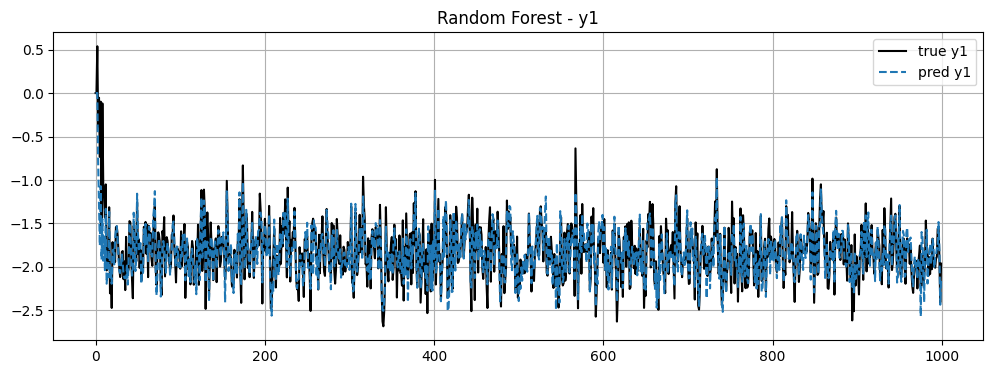

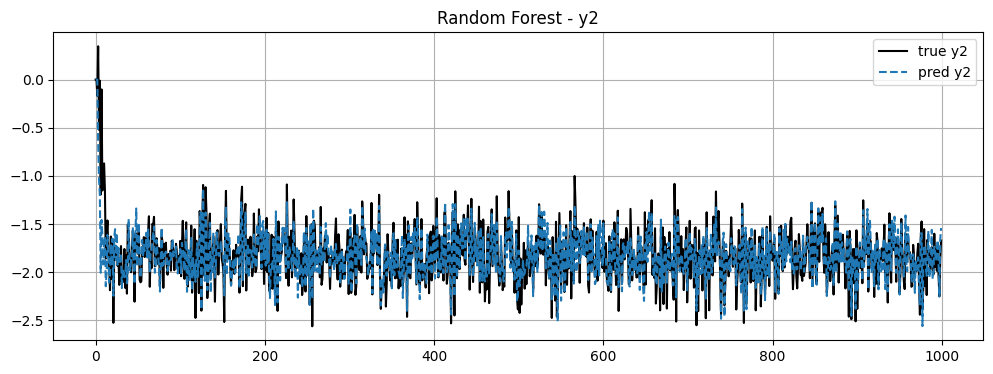

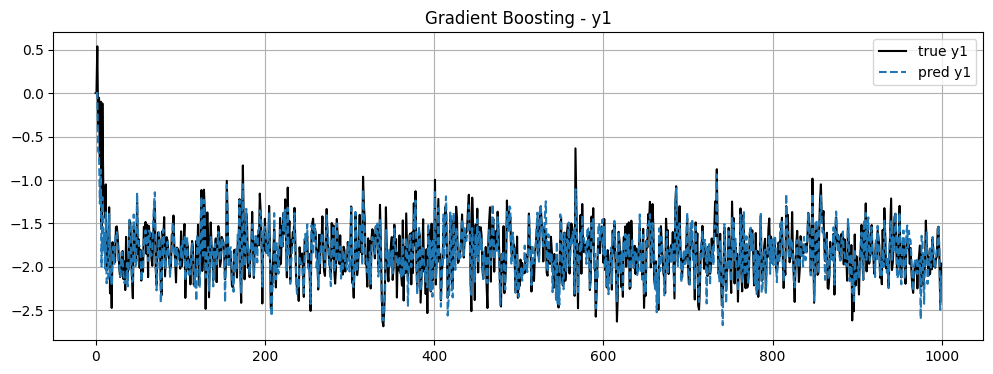

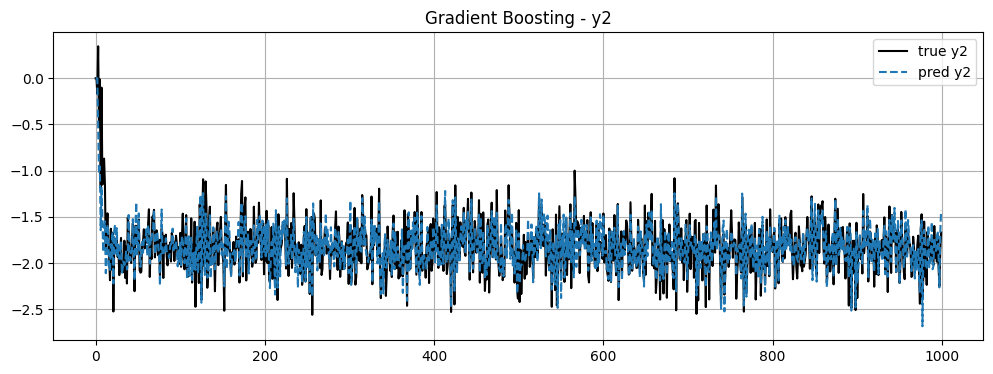

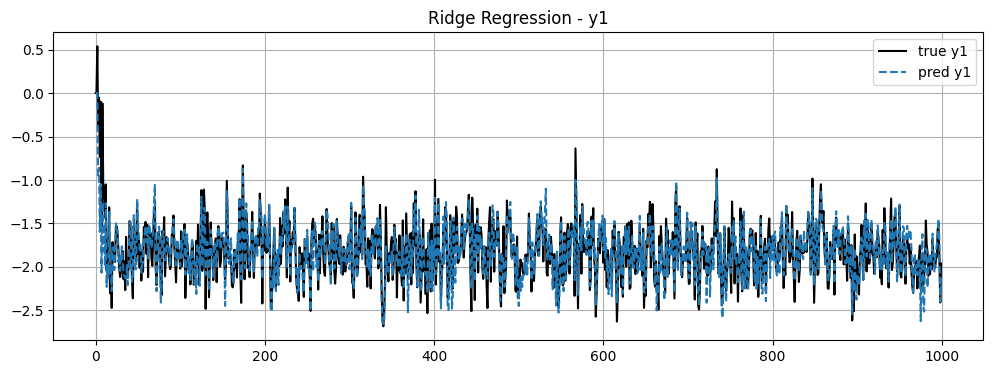

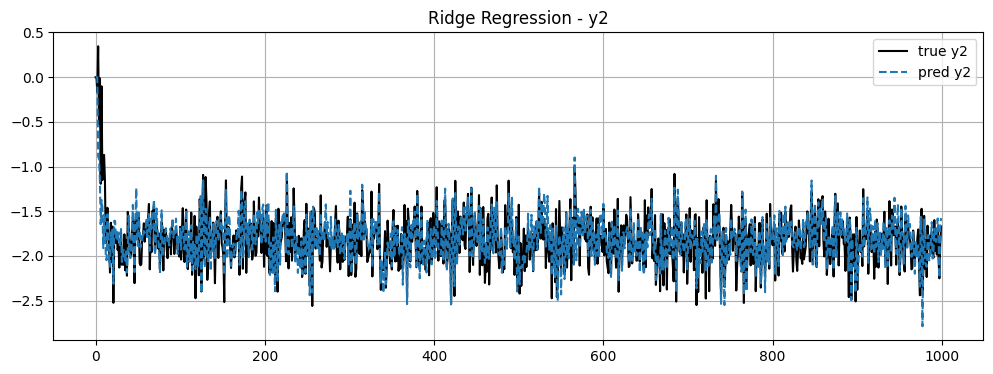

In [7]:
def rmse(Y_true, Y_pred):
    return np.sqrt(np.mean((Y_true - Y_pred)**2))

def nmse(Y_true, Y_pred):
    num = np.sum((Y_true - Y_pred)**2)
    den = np.sum((Y_true - Y_true.mean(axis=0))**2)
    return num / den


# Predictions on Uts1

Yhat_rf = recursive_prediction(Uts_p1, rf1, rf2, best_d, best_na, best_nb)
Yhat_xgb   = recursive_prediction(Uts_p1, xgb1, xgb2, best_d, best_na, best_nb)
Yhat_ridge = recursive_prediction(Uts_p1, ridge1, ridge2, best_d, best_na, best_nb)

print("Random Forest:", "RMSE =", rmse(Yts_p1, Yhat_rf), "NMSE =", nmse(Yts_p1, Yhat_rf))
print("XGBoost:", rmse(Yts_p1, Yhat_xgb), nmse(Yts_p1, Yhat_xgb))
print("Ridge:", rmse(Yts_p1, Yhat_ridge), nmse(Yts_p1, Yhat_ridge))



def plot_results(Y_true, Y_pred, title):

    plt.figure(figsize=(12,4))
    plt.plot(Y_true[:,0], label="true y1", color="black")
    plt.plot(Y_pred[:,0], "--", label="pred y1")
    plt.title(title + " - y1")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(Y_true[:,1], label="true y2", color="black")
    plt.plot(Y_pred[:,1], "--", label="pred y2")
    plt.title(title + " - y2")
    plt.legend()
    plt.grid()
    plt.show()


plot_results(Yts_p1, Yhat_rf, "Random Forest")
plot_results(Yts_p1, Yhat_xgb, "Gradient Boosting")
plot_results(Yts_p1, Yhat_ridge, "Ridge Regression")

***Task 2d***

Jusqu’ici nous utilisions des modèles “classiques”, ils ne comprennent pas vraiment le temps
Utilisons maintenant un LSTM (réseau de neurones), spécialisé pour les données temporelles

Le LSTM est utilisé ici, mais comme la séquence est de longueur 1, il n’exploite pas pleinement sa capacité à modéliser des dépendances temporelles longues. X_train.reshape(N, 1, features) **pq ? ** LSTM tres puissnat mais isi on le sous exploite



Training LSTM for y1...
Epoch 20/100 - Loss: 0.1342
Epoch 40/100 - Loss: 0.0919
Epoch 60/100 - Loss: 0.0949
Epoch 80/100 - Loss: 0.0665
Epoch 100/100 - Loss: 0.0692
Training LSTM for y2...
Epoch 20/100 - Loss: 0.0844
Epoch 40/100 - Loss: 0.1096
Epoch 60/100 - Loss: 0.1407
Epoch 80/100 - Loss: 0.1578
Epoch 100/100 - Loss: 0.0645
LSTM:
RMSE: 0.1468633188974181
NMSE: 0.20343983195925047


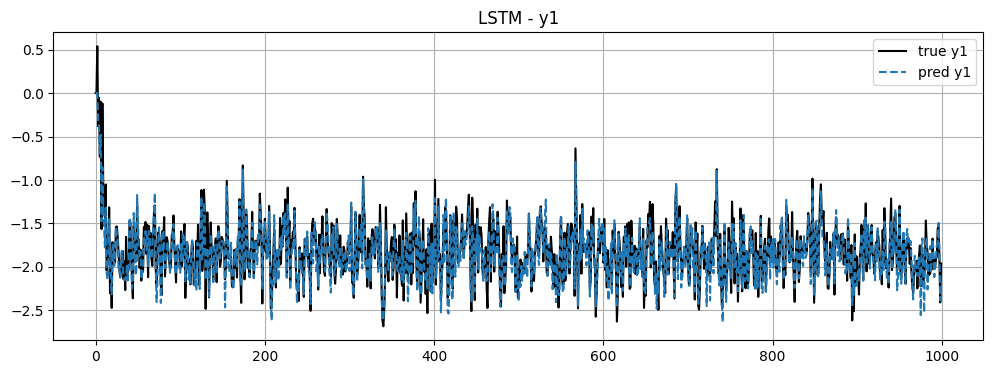

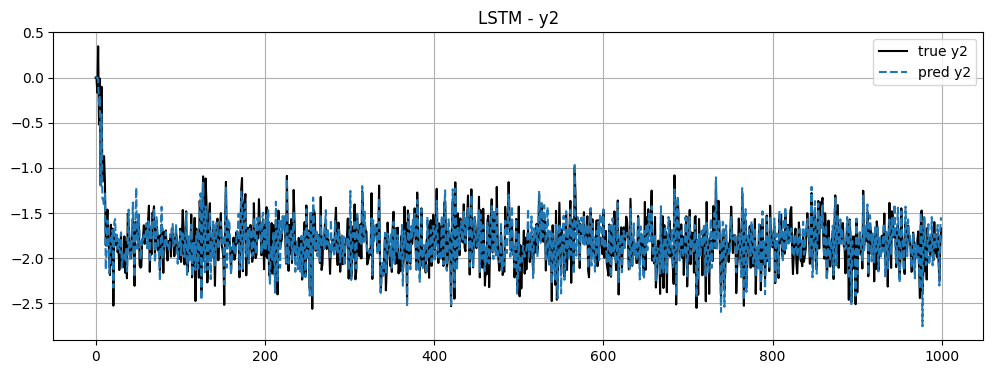

In [ ]:
# =======================================================
# Loss function (RMSE)
# =======================================================

def rmse_loss(y_pred, y_true):
    return torch.sqrt(torch.mean((y_pred - y_true) ** 2))

# =======================================================
# LSTM model
# =======================================================

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

# =======================================================
# Training function
# =======================================================

def train_lstm(X_train, Y_train, epochs=100, lr=0.001, batch_size=32):

    X_t = torch.tensor(X_train.reshape(X_train.shape[0], 1, X_train.shape[1]), dtype=torch.float32)
    Y_t = torch.tensor(Y_train, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_t, Y_t), batch_size=batch_size, shuffle=True)

    model = LSTMModel(input_size=X_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        for X_batch, Y_batch in loader:
            optimizer.zero_grad()
            loss = rmse_loss(model(X_batch), Y_batch)
            loss.backward()
            optimizer.step()

        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

    return model

# =======================================================
# Prediction (1-step)
# =======================================================

def predict_lstm(model, X):
    model.eval()
    X_t = torch.tensor(X.reshape(X.shape[0], 1, X.shape[1]), dtype=torch.float32)

    with torch.no_grad():
        return model(X_t).numpy()

# =======================================================
# Recursive prediction (LSTM)
# =======================================================

def recursive_prediction_lstm(U, model1, model2, d, na, nb):

    N = len(U)
    y1 = np.zeros(N)
    y2 = np.zeros(N)

    start = max(d + na, nb)

    for k in range(start, N-1):
        row = []

        # past outputs (predicted)
        for lag in range(d, d + na):
            row.append(y1[k - lag])
            row.append(y2[k - lag])

        # past inputs
        for lag in range(nb):
            row.append(U[k - lag, 0])
            row.append(U[k - lag, 1])

        X = np.array(row).reshape(1, -1)

        y1[k+1] = predict_lstm(model1, X).item()
        y2[k+1] = predict_lstm(model2, X).item()

    return np.column_stack([y1, y2])

# =======================================================
# TASK 2d — Training + prediction
# =======================================================

# Build dataset
Xtr, Ytr_super = build_features(Utr_p1, Ytr_p1, best_d, best_na, best_nb)

# Train LSTM
print("Training LSTM for y1...")
lstm1 = train_lstm(Xtr, Ytr_super[:,0], epochs=100)

print("Training LSTM for y2...")
lstm2 = train_lstm(Xtr, Ytr_super[:,1], epochs=100)

# Recursive prediction
Yhat_lstm = recursive_prediction_lstm(Uts_p1, lstm1, lstm2, best_d, best_na, best_nb)


print("LSTM:")
print("RMSE:", rmse(Yts_p1, Yhat_lstm))
print("NMSE:", nmse(Yts_p1, Yhat_lstm))

plot_results(Yts_p1, Yhat_lstm, "LSTM")


=== Hidden size = 16 ===
Epoch 20/100 - Train Loss: 0.2269 | Val Loss: 0.2446
Epoch 40/100 - Train Loss: 0.2115 | Val Loss: 0.2213
Epoch 60/100 - Train Loss: 0.2135 | Val Loss: 0.2129
Epoch 80/100 - Train Loss: 0.1959 | Val Loss: 0.2086
Epoch 100/100 - Train Loss: 0.2321 | Val Loss: 0.2067
Final → RMSE=0.2006 | NMSE=0.3796

=== Hidden size = 32 ===
Epoch 20/100 - Train Loss: 0.1630 | Val Loss: 0.2299
Epoch 40/100 - Train Loss: 0.2172 | Val Loss: 0.2146
Epoch 60/100 - Train Loss: 0.2361 | Val Loss: 0.2119
Epoch 80/100 - Train Loss: 0.1924 | Val Loss: 0.2057
Epoch 100/100 - Train Loss: 0.1719 | Val Loss: 0.2042
Final → RMSE=0.2001 | NMSE=0.3778

=== Hidden size = 64 ===
Epoch 20/100 - Train Loss: 0.2203 | Val Loss: 0.2229
Epoch 40/100 - Train Loss: 0.1744 | Val Loss: 0.2101
Epoch 60/100 - Train Loss: 0.1980 | Val Loss: 0.2068
Epoch 80/100 - Train Loss: 0.1852 | Val Loss: 0.2051
Epoch 100/100 - Train Loss: 0.1638 | Val Loss: 0.2070
Final → RMSE=0.2147 | NMSE=0.4347

=== Hidden size = 128

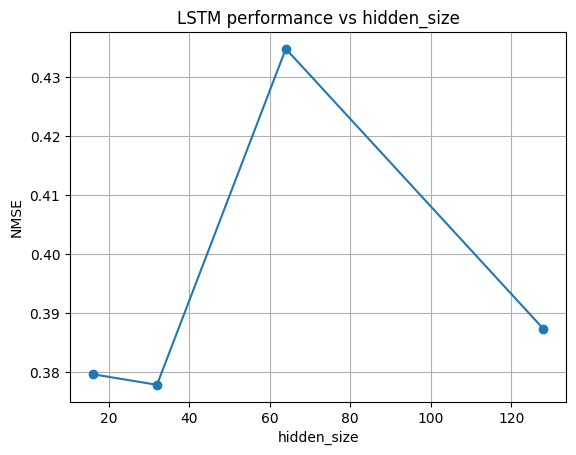


Best hidden_size = 32
Epoch 20/100 - Train Loss: 0.2381 | Val Loss: 0.2407
Epoch 40/100 - Train Loss: 0.2080 | Val Loss: 0.2151
Epoch 60/100 - Train Loss: 0.2123 | Val Loss: 0.2098
Epoch 80/100 - Train Loss: 0.1660 | Val Loss: 0.2063
Epoch 100/100 - Train Loss: 0.2151 | Val Loss: 0.2049


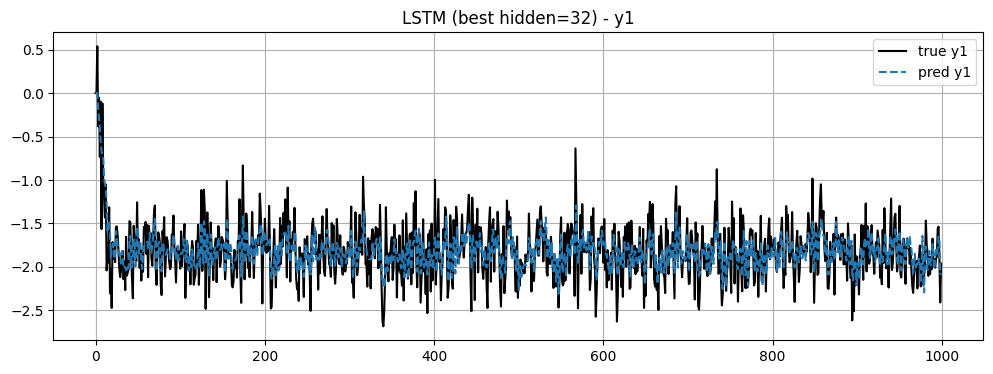

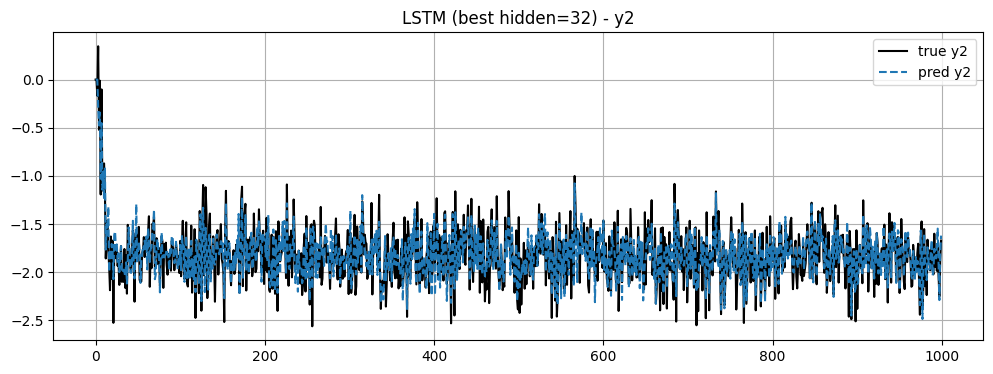

In [21]:
# =======================================================
# LOSS
# =======================================================
def rmse_loss(y_pred, y_true):
    return torch.sqrt(torch.mean((y_pred - y_true) ** 2))

# =======================================================
# LSTM MODEL (MIMO)
# =======================================================
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc   = nn.Linear(hidden_size, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# =======================================================
# TRAIN WITH VALIDATION (EARLY STOPPING)
# =======================================================
def train_lstm(X, Y, hidden_size=64, epochs=100, lr=0.001, batch_size=32):

    # split train/val (80/20)
    split = int(0.8 * len(X))
    Xtr, Xval = X[:split], X[split:]
    Ytr, Yval = Y[:split], Y[split:]

    Xtr_t = torch.tensor(Xtr.reshape(len(Xtr),1,-1), dtype=torch.float32)
    Ytr_t = torch.tensor(Ytr, dtype=torch.float32)

    Xval_t = torch.tensor(Xval.reshape(len(Xval),1,-1), dtype=torch.float32)
    Yval_t = torch.tensor(Yval, dtype=torch.float32)

    loader = DataLoader(TensorDataset(Xtr_t, Ytr_t), batch_size=batch_size, shuffle=True)

    model = LSTMModel(input_size=X.shape[1], hidden_size=hidden_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = np.inf
    patience = 10
    counter = 0

    for epoch in range(epochs):
        model.train()
        for Xb, Yb in loader:
            optimizer.zero_grad()
            loss = rmse_loss(model(Xb), Yb)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        with torch.no_grad():
            val_loss = rmse_loss(model(Xval_t), Yval_t).item()

        # affichage
        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f}")

        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model)
    return model

# =======================================================
# PREDICTION
# =======================================================
def predict_lstm(model, X):
    model.eval()
    X_t = torch.tensor(X.reshape(len(X),1,-1), dtype=torch.float32)
    with torch.no_grad():
        return model(X_t).numpy()

# =======================================================
# RECURSIVE PREDICTION
# =======================================================
def recursive_prediction_lstm(U, model, d, na, nb):

    N = len(U)
    y = np.zeros((N,2))
    start = max(d + na, nb)

    for k in range(start, N-1):
        row = []

        for lag in range(d, d+na):
            row += [y[k-lag,0], y[k-lag,1]]

        for lag in range(nb):
            row += [U[k-lag,0], U[k-lag,1]]

        X = np.array(row).reshape(1,-1)
        y[k+1] = predict_lstm(model, X)[0]

    return y

# =======================================================
# TASK 2d — FULL PIPELINE
# =======================================================

Xtr, Ytr_super = build_features(Utr_p1, Ytr_p1, best_d, best_na, best_nb)

hidden_sizes = [16, 32, 64, 128]
results = []

for h in hidden_sizes:
    print(f"\n=== Hidden size = {h} ===")

    model = train_lstm(Xtr, Ytr_super, hidden_size=h, epochs=100)

    Yhat = recursive_prediction_lstm(Uts_p1, model, best_d, best_na, best_nb)

    r = rmse(Yts_p1, Yhat)
    n = nmse(Yts_p1, Yhat)

    results.append((h, r, n))

    print(f"Final → RMSE={r:.4f} | NMSE={n:.4f}")

# =======================================================
# RESULTS
# =======================================================
print("\n=== Results ===")
for h, r, n in results:
    print(f"hidden={h} → RMSE={r:.4f}, NMSE={n:.4f}")

# =======================================================
# PLOT
# =======================================================
hs = [r[0] for r in results]
nmse_vals = [r[2] for r in results]

plt.plot(hs, nmse_vals, marker='o')
plt.xlabel("hidden_size")
plt.ylabel("NMSE")
plt.title("LSTM performance vs hidden_size")
plt.grid()
plt.show()

# =======================================================
# BEST MODEL
# =======================================================
best_h = min(results, key=lambda x: x[2])[0]
print(f"\nBest hidden_size = {best_h}")

best_model = train_lstm(Xtr, Ytr_super, hidden_size=best_h, epochs=100)
Yhat_best = recursive_prediction_lstm(Uts_p1, best_model, best_d, best_na, best_nb)

plot_results(Yts_p1, Yhat_best, f"LSTM (best hidden={best_h})")

**The LSTM model with hidden size 32 achieves the best performance in terms of RMSE and NMSE**. It captures nonlinear temporal dependencies more effectively than classical regression models, leading to improved predictive accuracy.


In [20]:
# =======================================================
# TASK 3 — FINAL DEPLOYMENT (LSTM)
# =======================================================

# 1. PARAMETER SELECTION (grid search)
best_d, best_na, best_nb = grid_search_params(
    Utr, Ytr,
    d_values=[0,1,2,3],
    na_values=[1,2,3],
    nb_values=[1,2,3]
)

# =======================================================
# 2. BUILD FEATURES
# =======================================================
Xtr, Ytr_super = build_features(Utr, Ytr, best_d, best_na, best_nb)

# =======================================================
# 3. TRAIN FINAL MODEL (LSTM MIMO)
# =======================================================
print("Training final LSTM model...")

best_hidden = 32
model = train_lstm(Xtr, Ytr_super, hidden_size=best_hidden, epochs=100)

# =======================================================
# 5. PREDICTIONS
# =======================================================
print("Generating predictions...")

Yhat1 = recursive_prediction_lstm(Uts1, model, best_d, best_na, best_nb)
Yhat2 = recursive_prediction_lstm(Uts2, model, best_d, best_na, best_nb)

# =======================================================
# 6. SAVE SUBMISSION
# =======================================================
np.savez("submission.npz", Yhat1=Yhat1, Yhat2=Yhat2)

print("Submission file saved successfully !")

Best parameters (d, na, nb): (0, 2, 1)
Training final LSTM model...
Epoch 20/100 - Train Loss: 0.1896 | Val Loss: 0.1856
Epoch 40/100 - Train Loss: 0.1019 | Val Loss: 0.1123
Epoch 60/100 - Train Loss: 0.1202 | Val Loss: 0.1045
Epoch 80/100 - Train Loss: 0.0727 | Val Loss: 0.0910
Epoch 100/100 - Train Loss: 0.0553 | Val Loss: 0.0825
Generating predictions...
Submission file saved successfully !
